# Phase 5: Exploratory Data Analysis (EDA) & Insights

**Objective:** Uncover patterns, trends, and actionable insights from the cleaned user dataset.

**Business Questions to Answer:**
1. What is the demographic profile of our users? (Age, Gender, Nationality)
2. Where are our users located geographically?
3. What is the data quality profile by region? (Which regions have the most missing IDs?)
4. Are there relationships between user attributes (Age, Country, ID completion)?
5. What actions should the business take based on these findings?

**Key Visualizations:**
- Age Distribution
- Gender Ratio
- Top Countries
- ID Completion by Region
- Registration Trends Over Time
- Correlation Heatmap

**Tools Used:**
- Matplotlib (Base visualization)
- Seaborn (Statistical visualizations)
- Pandas (Data manipulation)

In [36]:
# ============================================================
# SETUP: Find Project Root & Load Clean Dataset
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
from pathlib import Path




# ============================================================
# STEP 1: Find the project root by searching for 'data/processed/'
# ============================================================

def find_project_root(marker_folder="data/processed/"):
    """
    Searches the current directory and its parents until it finds 
    the folder containing the 'data/processed/' directory.
    """
    current_path = Path.cwd()
    print(current_path)

    while current_path !=current_path.parent:
        if(current_path/marker_folder).exists():
            return str(current_path)
        current_path = current_path.parent

    raise FileNotFoundError(f"Could not find '{marker_folder}' in any parent directory!")

# Find the root and switch to it
project_root = find_project_root()
os.chdir(project_root)
print(f"✅ Project root locked to: {os.getcwd()}")

# ============================================================
# STEP 2: Verify folder structure
# ============================================================
print("\nVerifying folder structure:")

folders_to_check = ["data/processed/","data/raw/", "src/","reports/"]
for folder in folders_to_check:
    exists = os.path.exists(folder)
    status = "✅" if exists else "❌"
    print(f"  {status} {folder}: {exists}")

# ============================================================
# STEP 3: Create reports/figures folder (if it doesn't exist)
# ============================================================
os.makedirs("reports/figures", exist_ok=True)
print("\n✅ reports/figures/ directory ready")

# ============================================================
# STEP 4: Set professional plotting style
# ============================================================

# Set professional plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Set figure size for all plots
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

# ============================================================
# STEP 5: Load the clean dataset
# ============================================================
print("\nLoading clean dataset...")
processed_dir = "data/processed/"
all_files = os.listdir(processed_dir)
print(all_files)

csv_files = []
for f in all_files:
    if f.endswith('.csv'):
        csv_files.append(f)
if csv_files:
    latest_csv = sorted(csv_files)[-1]
    filepath = os.path.join(processed_dir,latest_csv)
    df = pd.read_csv(filepath)


    print(f"✅ Loaded: {latest_csv}")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {len(df.columns)}")
    print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Quick preview
    print(f"\nFirst 3 rows:")
    display(df.head(3))
else:
    print("❌ No CSV files found in data/processed/")

C:\Users\Usman Khan\global-user-onboarding-analytics
✅ Project root locked to: C:\Users\Usman Khan\global-user-onboarding-analytics

Verifying folder structure:
  ✅ data/processed/: True
  ✅ data/raw/: True
  ✅ src/: True
  ✅ reports/: True

✅ reports/figures/ directory ready

Loading clean dataset...
['cleaned_users_2026-08-06_16-09-29.csv']
✅ Loaded: cleaned_users_2026-08-06_16-09-29.csv
   Shape: (4962, 46)
   Columns: 46
   Memory usage: 10.78 MB

First 3 rows:


,gender,email,phone,cell,nat,name_title,name_first,name_last,location_street_number,location_street_name,...,registration_month,registration_day_of_week,registration_quarter,dob_year,dob_month,age_group,days_since_registration,email_domain,is_top_country,region
0,female,kubra.erbay@example.com,(875)-635-8712,(276)-197-7714,TR,Ms,Kübra,Erbay,2787,Istiklal Cd,...,5,0,2,1964,11,60+,2278,example.com,False,Other
1,male,prhm.hmdy@example.com,069-74032840,0986-612-7065,IR,Mr,پرهام,احمدی,3758,حجاب,...,12,4,4,1993,2,26-40,6439,example.com,False,Other
2,female,laurie.knight@example.com,O27 J25-3249,H23 D22-6792,CA,Mrs,Laurie,Knight,1065,Parliament St,...,12,2,4,1971,9,41-60,1681,example.com,False,Americas


## Analysis 3.1: Age Distribution

**Objective:** Understand the age demographics of our user base.


ANALYSIS 3.1: AGE DISTRIBUTION

--- Summary Statistics ---
Mean Age: 53.2
Median Age: 53
Age Range: 25 - 81 years
Standard Deviation: 16.4

--- Age Group Distribution ---
age_group
18-25      60
26-40    1328
41-60    1710
60+      1864
Name: count, dtype: int64


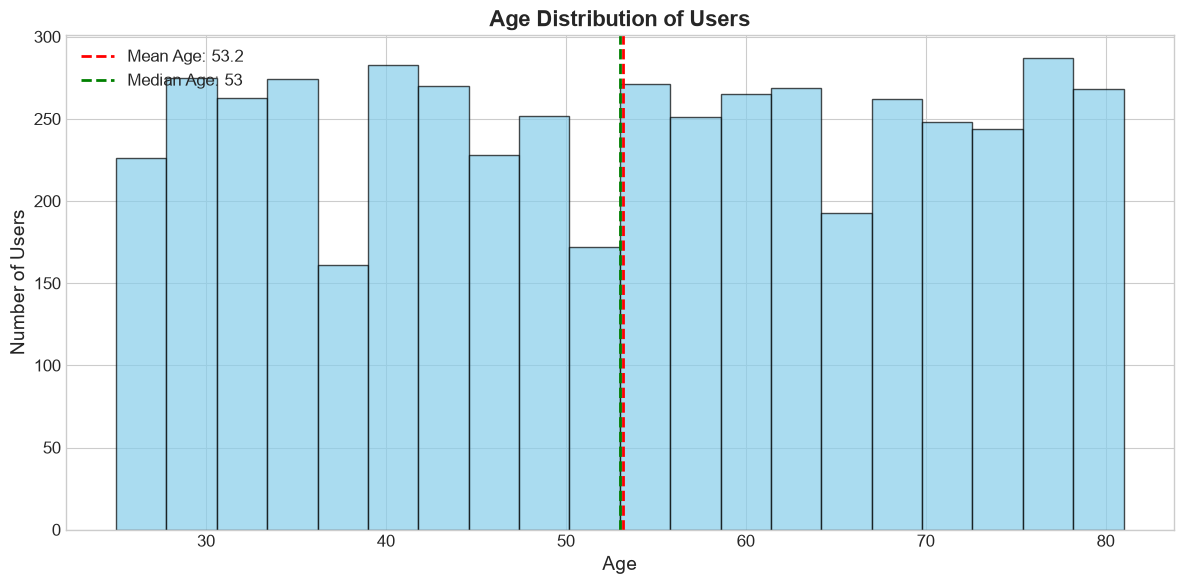


--- Key Insight ---
Most common age group: 60+ (1864 users)


In [70]:
# ============================================================
# ANALYSIS 3.1: Age Distribution
# ============================================================

print("\n" + "=" * 60)
print("ANALYSIS 3.1: AGE DISTRIBUTION")
print("=" * 60 + "\n")

#  Calculate summary statistics
print("--- Summary Statistics ---")
mean_age = df["dob_age"].mean()
median_age = df["dob_age"].median()
min_age = df["dob_age"].min()
max_age = df["dob_age"].max()
std_age = df["dob_age"].std()

print(f"Mean Age: {mean_age:.1f}")
print(f"Median Age: {median_age:.0f}")
print(f"Age Range: {min_age:.0f} - {max_age:.0f} years")
print(f"Standard Deviation: {std_age:.1f}")

#  Print age group distribution
print("\n--- Age Group Distribution ---")
print(df['age_group'].value_counts().sort_index())

# Step 3: Create histogram
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram
ax.hist(df["dob_age"], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical lines for mean and median
ax.axvline(mean_age, color='red', linestyle="--", linewidth=2, 
           label=f'Mean Age: {mean_age:.1f}')
ax.axvline(median_age, color="green", linestyle="--", linewidth=2, 
           label=f'Median Age: {median_age:.0f}')

# Formatting
ax.set_title('Age Distribution of Users', fontsize=16, fontweight='bold')
ax.set_xlabel('Age', fontsize=14)
ax.set_ylabel('Number of Users', fontsize=14)
ax.legend(fontsize=12)

plt.tight_layout()

# Save the figure
plt.savefig('reports/figures/age_distribution.png', dpi=300, bbox_inches='tight')

# Display the figure
plt.show()

# Step 4: Key Insight
print("\n--- Key Insight ---")
most_common_age_group = df['age_group'].value_counts().index[0]
print(f"Most common age group: {most_common_age_group} ({df['age_group'].value_counts().iloc[0]} users)")

### 📊 Analysis 3.1: Age Distribution - Business Insights

**Key Findings:**
- The **average age** of our users is **53.2 years old**, with a median of **53**.
- The largest age group is **60+** with **1,864 users (37.56%)**, followed by **41-60** with **1,727 users (34.8%)**.
- Only **1.2% (60 users)** are in the **18-25** age bracket.

**Business Implications:**
1. **Product Strategy:** The platform is heavily used by older demographics. UX should prioritize:
   - Larger font sizes
   - Clear, simple navigation
   - Accessibility features (color contrast, screen reader compatibility)

2. **Marketing Strategy:** Marketing campaigns should target older demographics through:
   - Facebook ads (higher penetration among 50+)
   - Traditional media (TV, radio) for brand awareness
   - Content marketing focused on retirement planning, health, or senior lifestyle

3. **Growth Opportunity:** The lack of young users (18-25) suggests:
   - We are not reaching younger demographics through current channels
   - Need to explore TikTok, Instagram, or influencer marketing
   - Consider product features that appeal to younger users (gamification, social sharing)

**Recommendation:**
- **Immediate:** Conduct user interviews with our 60+ users to understand what they value most about the platform.
- **Medium-term:** Launch a targeted campaign to attract users aged 25-40, who are underrepresented compared to industry benchmarks.